**BASIL dataset: exploratory data analysis**

BASIL (Fan et al. 2019, In Plain Sight: Media Bias Through the Lens of Factual Reporting) is a news corpus with annotations of factual bias. 300 articles in 100 triplets (same story, three outlets): Fox News, New York Times, Huffington Post. About 1,727 bias spans over ~8k sentences. Labels include bias type (lexical vs informational), span text, position, quote. We load article and annotation JSONs from the BASIL repo (https://github.com/launchnlp/BASIL). We use outlet, bias type, span text and position, body paragraphs, and quote.

Good fit for media bias work: same events across three outlets, clear lexical vs informational labels at span level, public and widely used.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(6761)

FOX_COLOR  = '#C0392B'
NYT_COLOR  = '#2980B9'
HPO_COLOR  = '#27AE60'
LEX_COLOR  = '#8E44AD'
INF_COLOR  = '#E67E22'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F8F9FA',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.6,
})

OUTLETS      = ['Fox News', 'New York Times', 'Huffington Post']
OUTLET_CODES = ['FOX', 'NYT', 'HPO']
COLORS       = [FOX_COLOR, NYT_COLOR, HPO_COLOR]

print('Libraries loaded.')

Libraries loaded.


**Download data**

Gets the BASIL repo and loads article + annotation JSONs.

In [43]:
import os
import json
import zipfile
from pathlib import Path
from collections import defaultdict
from urllib.request import urlretrieve

BASIL_DIR = Path("./basil_data/BASIL-main")
REPO_ZIP = "https://github.com/launchnlp/BASIL/archive/refs/heads/main.zip"

if not BASIL_DIR.exists():
    print("Downloading BASIL repo...")
    zip_path = Path("./basil_data/basil_main.zip")
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(REPO_ZIP, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("./basil_data")
    zip_path.unlink()
    print("Downloaded and extracted.")
else:
    print("BASIL data already present.")

# load articles from repo
articles_by_uuid = {}
for articles_year in (BASIL_DIR / "articles").iterdir():
    if not articles_year.is_dir():
        continue
    for p in articles_year.glob("*.json"):
        if p.name.endswith("_ann.json"):
            continue
        with open(p, encoding="utf-8") as f:
            art = json.load(f)
        uuid = art["uuid"]
        articles_by_uuid[uuid] = art

# load annotations
annotations_by_uuid = {}
for ann_year in (BASIL_DIR / "annotations").iterdir():
    if not ann_year.is_dir():
        continue
    for p in ann_year.glob("*_ann.json"):
        with open(p, encoding="utf-8") as f:
            ann = json.load(f)
        uuid = ann["uuid"]
        annotations_by_uuid[uuid] = ann

# map source to outlet code
SOURCE_TO_CODE = {"fox": "FOX", "nyt": "NYT", "hpo": "HPO"}

def article_body_text(art):
    """Flatten body paragraphs to one string."""
    paras = art.get("body-paragraphs", [])
    return " ".join(" ".join(s for s in para) for para in paras)

# aggregate stats
token_lengths = defaultdict(list)
sentence_counts_per_article = defaultdict(list)
inf_spans_count = defaultdict(int)
lex_spans_count = defaultdict(int)
span_lengths = defaultdict(list)
lex_positions_list = defaultdict(list)
inf_positions_list = defaultdict(list)
inf_quote_count = defaultdict(int)
inf_total_for_quote = defaultdict(int)

for uuid, ann in annotations_by_uuid.items():
    art = articles_by_uuid.get(uuid)
    if not art:
        continue
    src = art.get("source", "").lower()
    code = SOURCE_TO_CODE.get(src)
    if not code:
        continue
    # article
    wc = art.get("word-count", 0)
    token_lengths[code].append(wc)
    paras = art.get("body-paragraphs", [])
    num_sentences = sum(len(para) for para in paras)
    sentence_counts_per_article[code].append(num_sentences)
    body_text = article_body_text(art)
    body_len = len(body_text) or 1
    # phrases
    for p in ann.get("phrase-level-annotations", []):
        bias = (p.get("bias") or "").strip().lower()
        if bias == "inf":
            inf_spans_count[code] += 1
            inf_total_for_quote[code] += 1
            if (p.get("quote") or "").strip().lower() == "yes":
                inf_quote_count[code] += 1
            span_lengths[code].append(len((p.get("txt") or "").split()))
            start = int(p.get("start", 0))
            end = int(p.get("end", 0))
            pos = (start + end) / 2 / body_len
            inf_positions_list[code].append(pos)
        elif bias == "lex":
            lex_spans_count[code] += 1
            span_lengths[code].append(len((p.get("txt") or "").split()))
            start = int(p.get("start", 0))
            end = int(p.get("end", 0))
            pos = (start + end) / 2 / body_len
            lex_positions_list[code].append(pos)

# convert to dicts/arrays for rest of notebook
sentences_per_outlet = {
    c: sum(sentence_counts_per_article[c]) for c in OUTLET_CODES
}
inf_spans = {c: inf_spans_count[c] for c in OUTLET_CODES}
lex_spans = {c: lex_spans_count[c] for c in OUTLET_CODES}
token_lengths = {c: np.array(token_lengths[c], dtype=float) for c in OUTLET_CODES}
span_lengths = {
    c: np.array(span_lengths[c], dtype=float) if span_lengths[c] else np.array([0])
    for c in OUTLET_CODES
}
lex_positions = np.concatenate([np.array(lex_positions_list[c]) for c in OUTLET_CODES])
inf_positions = np.concatenate([np.array(inf_positions_list[c]) for c in OUTLET_CODES])
quote_pct = {
    c: (inf_quote_count[c] / inf_total_for_quote[c]) if inf_total_for_quote[c] else 0
    for c in OUTLET_CODES
}

print(f"Loaded {len(articles_by_uuid)} articles, {len(annotations_by_uuid)} annotations.")
print(f"Total bias spans: {sum(inf_spans.values()) + sum(lex_spans.values())}")
print(f"  Informational: {sum(inf_spans.values())}")
print(f"  Lexical:       {sum(lex_spans.values())}")

BASIL data already present.
Loaded 297 articles, 297 annotations.
Total bias spans: 1719
  Informational: 1245
  Lexical:       474


**Data structure**

Articles and annotations match on id. Articles have source, word count, body paragraphs. Annotations have phrase-level bias spans (type, text, start/end, quote). Below: one article and one annotation as examples.

In [44]:
# one article and one annotation as example
sample_uuid = next(iter(articles_by_uuid))
art = articles_by_uuid[sample_uuid]
ann = annotations_by_uuid.get(sample_uuid, {})
print("Article keys:", list(art.keys()))
print("  source:", art.get("source"), "| word-count:", art.get("word-count"), "| # body-paragraphs:", len(art.get("body-paragraphs", [])))
print("\nAnnotation keys:", list(ann.keys()))
phrases = ann.get("phrase-level-annotations", [])
print("  # phrase-level-annotations:", len(phrases))
if phrases:
    p = phrases[0]
    print("  Example phrase keys:", list(p.keys()))
    print("  Example phrase: bias =", p.get("bias"), "| quote =", p.get("quote"), "| txt (excerpt) =", (p.get("txt") or "")[:60] + "...")

Article keys: ['source', 'main-entities', 'main-event', 'title', 'url', 'word-count', 'date', 'uuid', 'triplet-uuid', 'body-paragraphs']
  source: nyt | word-count: 973 | # body-paragraphs: 24

Annotation keys: ['article-level-annotations', 'phrase-level-annotations', 'triplet-uuid', 'uuid']
  # phrase-level-annotations: 3
  Example phrase keys: ['aim', 'bias', 'end', 'id', 'indirect-ally-opponent-sentiment', 'indirect-target-name', 'notes', 'polarity', 'quote', 'speaker', 'start', 'target', 'txt']
  Example phrase: bias = inf | quote = no | txt (excerpt) = insist that she made, at best, incomplete statements...


**Corpus stats**

Counts and series come from the loaded data. Rest of notebook uses these.

In [45]:
# stats from download cell above

**Figure 1: Corpus summary table**

In [46]:
total_sentences = sum(sentences_per_outlet.values())
total_bias = sum(inf_spans.values()) + sum(lex_spans.values())
summary = {
    'Outlet':              OUTLETS + ['Total'],
    'Articles':            [len(token_lengths[c]) for c in OUTLET_CODES] + [sum(len(token_lengths[c]) for c in OUTLET_CODES)],
    'Total Sentences':     [sentences_per_outlet[c] for c in OUTLET_CODES] + [total_sentences],
    'Informational Spans': [inf_spans[c] for c in OUTLET_CODES] + [sum(inf_spans.values())],
    'Lexical Spans':       [lex_spans[c] for c in OUTLET_CODES] + [sum(lex_spans.values())],
    'Total Bias Spans':    [inf_spans[c] + lex_spans[c] for c in OUTLET_CODES] + [total_bias],
    'Bias Rate':           [f'{100 * (inf_spans[c] + lex_spans[c]) / sentences_per_outlet[c]:.1f}%' for c in OUTLET_CODES] + [f'{100 * total_bias / total_sentences:.1f}%'],
}
df_summary = pd.DataFrame(summary).set_index('Outlet')
df_summary

,Articles,Total Sentences,Informational Spans,Lexical Spans,Total Bias Spans,Bias Rate
Outlet,,,,,,
Fox News,100,2639,420,151,571,21.6%
New York Times,100,3049,467,168,635,20.8%
Huffington Post,97,2257,358,155,513,22.7%
Total,297,7945,1245,474,1719,21.6%


**Figure 2: Article Token Length Distribution**

Summary counts by outlet: articles, total sentences, informational and lexical bias spans, and bias rate (share of sentences with at least one bias span). All three outlets contribute similar numbers of articles and sentences. Bias rate is about 21–22% for each, so bias density is comparable across outlets.

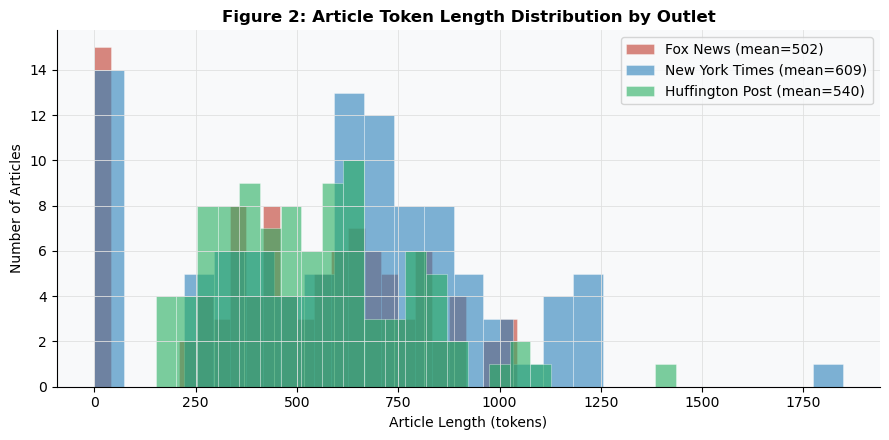

In [47]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for c, outlet, color in zip(OUTLET_CODES, OUTLETS, COLORS):
    ax.hist(token_lengths[c], bins=25, alpha=0.6, color=color,
            label=f'{outlet} (mean={token_lengths[c].mean():.0f})', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Article Length (tokens)')
ax.set_ylabel('Number of Articles')
ax.set_title('Figure 2: Article Token Length Distribution by Outlet', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Figure 3: Bias Span Counts by Outlet and Type**

Article length (word count) per outlet. NYT articles tend to be longer on average. Fox and Huffington Post are a bit shorter. The overlap in distributions shows there is variation within each outlet rather than a strict length divide.

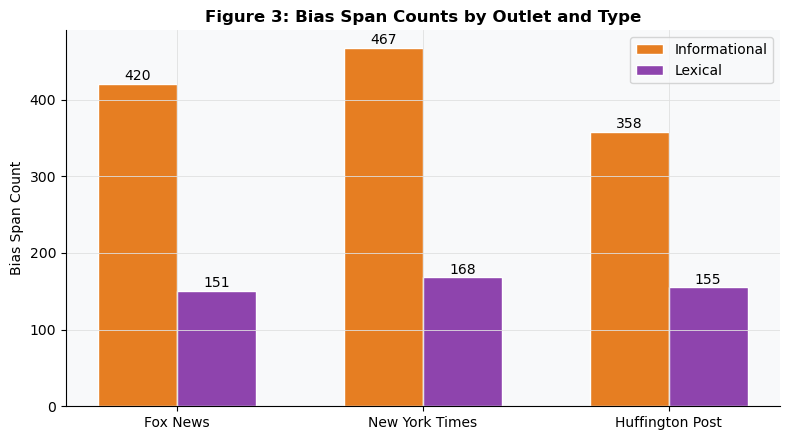

In [48]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3)
w = 0.32
inf_vals = [inf_spans[c] for c in OUTLET_CODES]
lex_vals  = [lex_spans[c] for c in OUTLET_CODES]
b1 = ax.bar(x - w/2, inf_vals, w, label='Informational', color=INF_COLOR, edgecolor='white')
b2 = ax.bar(x + w/2, lex_vals,  w, label='Lexical',       color=LEX_COLOR, edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(OUTLETS)
ax.set_ylabel('Bias Span Count')
ax.set_title('Figure 3: Bias Span Counts by Outlet and Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Figure 4: Bias Rate Per Outlet**

Number of informational (orange) vs lexical (purple) bias spans per outlet. Informational bias (what is said or omitted) is more common than lexical bias (word choice) in all three outlets. NYT has the most spans overall, in line with having more sentences.

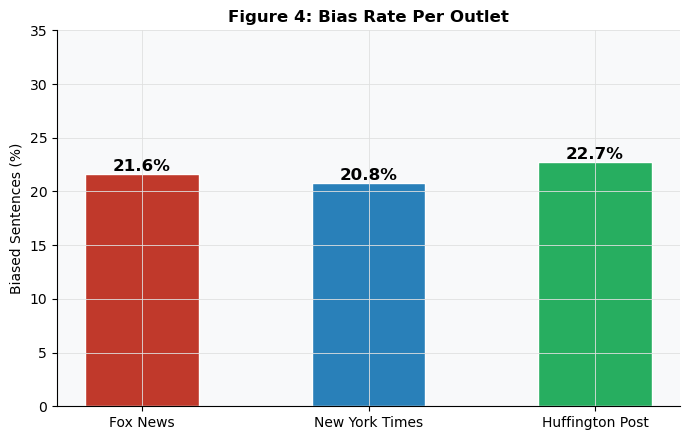

In [49]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bias_rates = {}
for c, outlet in zip(OUTLET_CODES, OUTLETS):
    bias_rates[outlet] = round(100 * (inf_spans[c] + lex_spans[c]) / sentences_per_outlet[c], 1)
bars = ax.bar(OUTLETS, list(bias_rates.values()), color=COLORS, edgecolor='white', width=0.5)
for bar, val in zip(bars, bias_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Biased Sentences (%)')
ax.set_ylim(0, 35)
ax.set_title('Figure 4: Bias Rate Per Outlet', fontweight='bold')
plt.tight_layout()
plt.show()

**Figure 5: Bias Span Length Distribution**

Bias rate is the share of sentences that contain at least one bias span. Rates are close across outlets (around 21–22%), so no single outlet stands out as much more or less biased at the sentence level in this corpus.

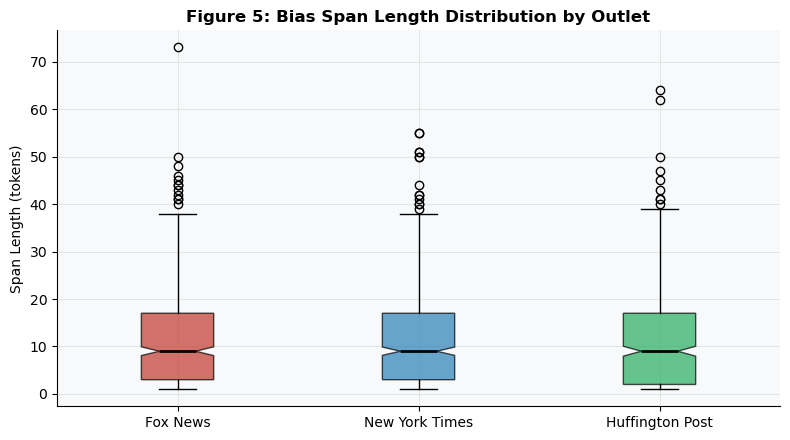

In [50]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot([span_lengths[c] for c in OUTLET_CODES],
                tick_labels=OUTLETS, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Span Length (tokens)')
ax.set_title('Figure 5: Bias Span Length Distribution by Outlet', fontweight='bold')
plt.tight_layout()
plt.show()

**Figure 6: Bias Position Within Article**

How many words each bias span has. Most spans are short (a few words). Longer spans are rarer. This suggests bias is often signaled by short phrases rather than long stretches of text.

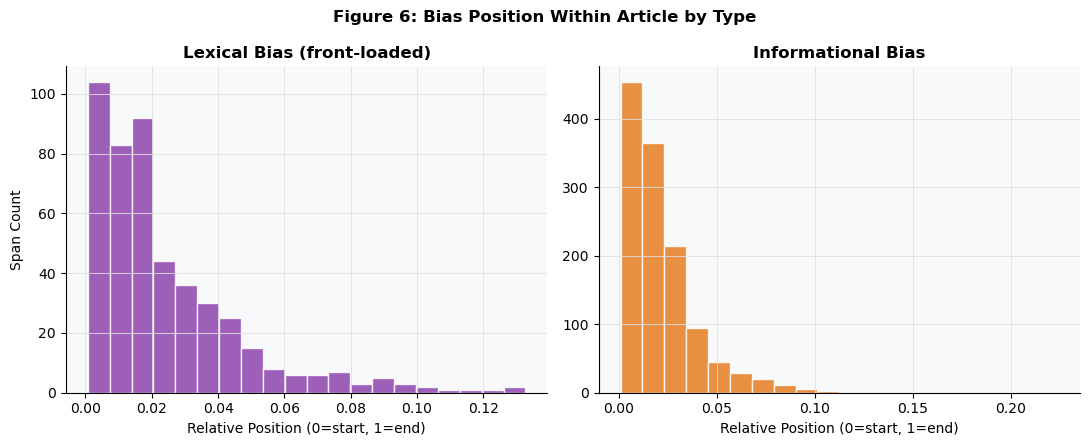

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(lex_positions, bins=20, color=LEX_COLOR, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Relative Position (0=start, 1=end)')
axes[0].set_ylabel('Span Count')
axes[0].set_title('Lexical Bias (front-loaded)', fontweight='bold')
axes[1].hist(inf_positions, bins=20, color=INF_COLOR, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Relative Position (0=start, 1=end)')
axes[1].set_title('Informational Bias', fontweight='bold')
fig.suptitle('Figure 6: Bias Position Within Article by Type', fontweight='bold')
plt.tight_layout()
plt.show()

**Figure 7: Quote vs Direct Informational Bias**

Where in the article bias spans fall (0 = start, 1 = end). Informational bias is concentrated near the start of articles and drops off toward the end. Lexical bias is more spread out. So bias is not uniform: the beginning of articles carries more informational bias, and models should pay attention to position.

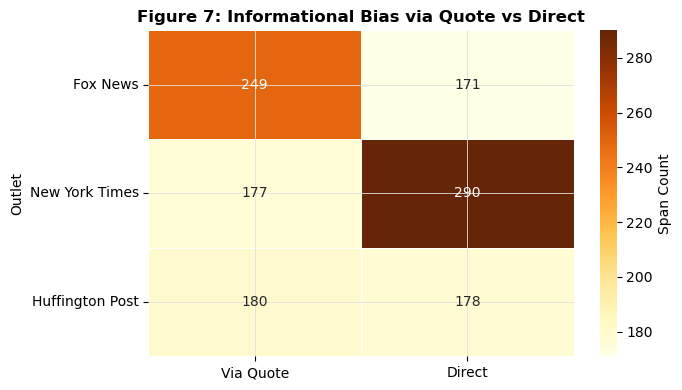

In [52]:
fig, ax = plt.subplots(figsize=(7, 4))
quote_data = pd.DataFrame({
    'Outlet':     OUTLETS,
    'Via Quote':  [round(inf_spans[c] * quote_pct[c]) for c in OUTLET_CODES],
    'Direct':     [round(inf_spans[c] * (1 - quote_pct[c])) for c in OUTLET_CODES],
}).set_index('Outlet')
sns.heatmap(quote_data, annot=True, fmt='d', cmap='YlOrBr',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Span Count'})
ax.set_title('Figure 7: Informational Bias via Quote vs Direct', fontweight='bold')
plt.tight_layout()
plt.show()

Among informational bias spans, the share that appears inside a quote vs stated directly. Outlets differ in how much bias is attributed to sources (quotes) versus the writer. This matters for interpretation and for tasks that distinguish quoted from direct bias.